In [3]:

from __future__ import annotations

import operator
from typing import TypedDict, List, Annotated

from pydantic import BaseModel, Field
from langgraph.graph import StateGraph, START, END
from langgraph.types import Send

from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from pathlib import Path

In [4]:
class Task(BaseModel):
  id: int
  title: str
  brief: str = Field(..., description="What to cover.")

class Plan(BaseModel):
  blog_title: str
  tasks: List[Task]

In [5]:
class State(TypedDict):
  topic: str
  plan: Plan
  sections: Annotated[List[str], operator.add]
  final: str

In [6]:

llm = ChatOpenAI(model="gpt-4.1-mini")

In [7]:
def orchestrator(state: State) -> dict:
  plan = llm.with_structured_output(Plan).invoke(
    [
      SystemMessage(content="Create a blog plan with 5-7 sections on the following topic."),
      HumanMessage(content=f"Topic: {state['topic']}")
    ]
  )

  return {"plan":plan}

In [8]:
def fanout(state: State):
  return [Send("worker", {"task":task, "topic":state["topic"], "plan":state["plan"]}) for task in state["plan"].tasks]

In [9]:
def worker(payload: dict) -> dict:
  task = payload["task"]
  topic = payload["topic"]
  plan = payload["plan"]

  blog_title = plan.blog_title

  section_md = llm.invoke(
    [
      SystemMessage(content="Write one clean Markdown section."),
      HumanMessage( content=( 
        f"Blog: {blog_title}\n"
        f"Topic: {topic}\n\n"
        f"Section: {task.title}\n"
        f"Brief: {task.brief}\n\n"
        "Return only the section content in Markdown."
        )
      )
    ]
  ).content.strip()

  return {"sections": [section_md]}


In [10]:
import re

def reducer(state: State) -> dict:
    print("SECTIONS:", state["sections"])

    title = str(state['plan'].blog_title)

    body = "\n\n".join(state['sections']).strip()

    final_md = f"# {title}\n\n{body}\n"

    safe_title = re.sub(r"[^a-zA-Z0-9 ]", "", title)
    filename = "Basic_" + safe_title.lower().replace(" ", "_") + ".md"

    output_path = Path(filename)
    output_path.write_text(final_md, encoding="utf-8")

    print("FILE SAVED:", filename)

    return {"final": final_md}


In [11]:
g = StateGraph(State)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

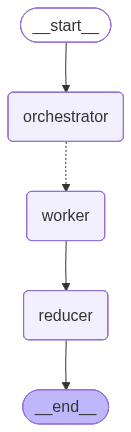

In [12]:
g.add_edge(START, "orchestrator")
g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

app

In [13]:
app.invoke({"topic": "Write a blog on Self Attention"})

SECTIONS: ['## Introduction to Self-Attention\n\nIn the realm of neural networks, **attention mechanisms** have revolutionized how models process and prioritize information. Attention allows a model to selectively focus on different parts of input data, much like how humans pay attention to relevant details when solving a problem. This selective focus helps improve performance in tasks involving sequences or structured data, such as language translation, image captioning, and more.\n\n**Self-attention** is a specialized form of attention where a model attends to different positions within the same input sequence to better understand the relationships between elements. Instead of just looking at external data, self-attention enables the model to weigh and aggregate information from all parts of the input relative to each other. This mechanism captures dependencies regardless of distance in the sequence, overcoming limitations of traditional methods like recurrent neural networks (RNNs),

{'topic': 'Write a blog on Self Attention',
 'plan': Plan(blog_title='Understanding Self-Attention: The Core of Modern Deep Learning Models', tasks=[Task(id=1, title='Introduction to Self-Attention', brief='Explain the concept of attention in neural networks and introduce self-attention as a mechanism. Discuss why self-attention is important and its role in modern deep learning architectures.'), Task(id=2, title='How Self-Attention Works', brief='Dive into the mechanics of self-attention. Explain queries, keys, and values, and how attention scores are computed. Use simple examples and diagrams to illustrate the process.'), Task(id=3, title='Self-Attention vs Traditional Attention Mechanisms', brief='Compare self-attention with other attention methods, such as encoder-decoder attention. Highlight the advantages of self-attention in capturing contextual relationships.'), Task(id=4, title='Applications of Self-Attention in Deep Learning', brief='Discuss various applications, including Tra